# LLM Facilitation Corpus Example Usage
This notebook demonstrates basic usage of the LLM-facilitated group decision-making dataset (*"Bringing Everyone to the Table: An Experimental Study of LLM-Facilitated Group Decision Making"*) using ConvoKitAI.

Groups of 5 participants chat to choose which of three fictional cities (Eldoron, Myloria, Cragnio) should host a sporting event. Each participant holds a different subset of facts about the cities, and each group gets one of four facilitation treatments: **None**, **Message** (a cue to share information), **Human** facilitator, or **LLM** (GPT-4o) facilitator.

We will explore the corpus size, the speaker / conversation / utterance metadata, the LLM facilitator's inputs and outputs, information sharing, and the post-task surveys, and then evaluate the facilitators with `convokitai_evaluation` (CIG, claim convergence, and redirection).

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from convokitai import Corpus

# Load corpus
corpus = Corpus(filename="llm_facilitation_corpus")
corpus.print_summary_stats()

Number of Speakers: 1807
Number of Utterances: 19331
Number of Conversations: 332
Number of AI Speakers: 77
Number of Assistants: 0
Number of Supports: 0


In [2]:
# Shared plotting style: one fixed color per treatment, used in every chart below
TREATMENTS = ["None", "Message", "Human", "LLM"]
TREATMENT_COLORS = {"None": "#2a78d6", "Message": "#eb6834", "Human": "#1baf7a", "LLM": "#eda100"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": "#e5e5e2", "grid.linewidth": 0.8})


def treatment_bar(values, title, ylabel, fmt="{:.0f}"):
    """Bar chart of one value per treatment, with direct value labels."""
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(TREATMENTS, [values[t] for t in TREATMENTS], width=0.6,
                  color=[TREATMENT_COLORS[t] for t in TREATMENTS])
    ax.bar_label(bars, labels=[fmt.format(values[t]) for t in TREATMENTS], padding=3)
    ax.margins(y=0.12)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="x", visible=False)
    plt.show()

## 1. Corpus-level Metadata
The corpus records the source study, the mapping from treatment names to short labels, and the bank of 30 facts used in the task. `has_ai` is `True` because the LLM facilitator is an AI speaker.

In [3]:
print("has_ai:", corpus.has_ai)
print("ai_meta:", corpus.ai_meta)
print("source:", corpus.meta["source"])
pd.Series(corpus.meta["treatment_labels"], name="treatment_label").to_frame()

has_ai: True
ai_meta: {}
source: Bringing Everyone to the Table: An Experimental Study of LLM-Facilitated Group Decision Making (Microsoft Research, GRAIL)


,treatment_label
noFacilitator_noCue_defaultHPT,None
noFacilitator_withCue_defaultHPT,Message
humanFacilitation_noCue_defaultHPT,Human
scoreboardFacilitation_noCue_defaultHPT,LLM


Each fact belongs to one city, has a polarity (positive / neutral / negative), and a visibility: **Public** facts are given to everyone, **Shared** facts to a few players, and **Private** facts to a single player. Utterances refer to facts by ID (`E1`–`E10`, `M1`–`M10`, `C1`–`C10`), which we rebuild here the same way as `analysis.ipynb`.

In [4]:
df_facts = pd.DataFrame(corpus.meta["facts"]).sort_values("sports_option").reset_index(drop=True)
df_facts["fact_id"] = df_facts["sports_option"].str[0] + pd.Series(list(np.arange(10) + 1) * 3).astype(str)
df_facts = df_facts.set_index("fact_id")
print(pd.crosstab(df_facts["sports_option"], df_facts["polarity"]))
print()
print(pd.crosstab(df_facts["sports_option"], df_facts["visibility"]))
df_facts.head(10)

polarity       Negative  Neutral  Positive
sports_option                             
Cragnio               4        2         4
Eldoron               1        2         7
Myloria               3        2         5

visibility     Private  Public  Shared
sports_option                         
Cragnio              5       3       2
Eldoron              6       2       2
Myloria              4       2       4


,sports_option,visibility,polarity,sports_players,sports_info,sports_dims
fact_id,,,,,,
C1,Cragnio,Private,Positive,Orange,Residents have a reputation for being friendly...,Community
C2,Cragnio,Public,Positive,Everyone,City's dry season coincides with the event dat...,Weather
C3,Cragnio,Public,Positive,Everyone,Shopping centers are popular with visitors,Tourism
C4,Cragnio,Public,Neutral,Everyone,Considered a hub for biotech in the region,Misc
C5,Cragnio,Private,Neutral,Blue,Recent archeological dig featured in a magazine,Misc
C6,Cragnio,Private,Negative,Blue,"In the past, residents have complained about n...",Community
C7,Cragnio,Private,Negative,Red,Variety of international cuisine may be limited,Tourism
C8,Cragnio,Shared,Negative,"Green, Pink",Some visitors with cars complain about parking...,Transportation
C9,Cragnio,Private,Negative,Orange,Only a few activities geared towards families ...,Tourism


## 2. Speakers
Speakers are the five color-named participants, human facilitators (in the Human treatment), and one AI facilitator per LLM game. ConvoKitAI marks AI speakers with `is_ai` and stores their generation config in `ai_meta`.

In [5]:
speaker_types = Counter(
    ("AI" if s.is_ai else "human", s.meta.get("game_role")) for s in corpus.iter_speakers()
)
pd.Series(speaker_types, name="count").rename_axis(["type", "game_role"]).to_frame()

,,count
type,game_role,
human,participant,1642
AI,facilitator,77
human,facilitator,88


In [6]:
ai_speaker = next(s for s in corpus.iter_speakers() if s.is_ai)
print(f"Speaker {ai_speaker.id}: is_ai={ai_speaker.is_ai}")
print("meta:", dict(ai_speaker.meta))
print("role:", ai_speaker.ai_meta["role"])
config = ai_speaker.ai_meta["config"]
for key, value in config.items():
    if key != "prompt":
        print(f"config.{key}: {value}")
print("\nSystem prompt:\n" + config["prompt"])

Speaker 01J9482GE8N55EH358ZZF19EKJ_facilitator_ai: is_ai=True
meta: {'name': 'Facilitator', 'game_role': 'facilitator', 'game_id': '01J9482GE8N55EH358ZZF19EKJ', 'platform_sender_id': 'ai'}
role: public assistant
config.model: gpt-4o-internal-07122024
config.response_format: json (MESSAGE, RATIONALE)
config.request_interval_sec: 90
config.require_llm_message: True

System prompt:
A group of decision makers are meeting to decide on which of three cities (Eldoron, Myloria, Cragnio) should host a large sporting event. 
    As a facilitator for this meeting, your specific role is help the group make a decision by, first, making sure that everyone is heard from and shares what they know and, second, acting as a scoreboard and keeping track of pros and cons. 
    People may have different information about what is being discussed in this meeting, so encourage everyone to share all of the relevant information they have.
    You will periodically receive the transcript of the group's conversati

In [7]:
human = corpus.get_speaker(next(iter(corpus.get_conversation(ai_speaker.meta["game_id"]).ai_meta["alias"])))
print(f"Speaker {human.id}: is_ai={human.is_ai}, ai_meta={human.ai_meta}")
for key, value in human.meta.items():
    if key != "player_content":
        print(f"{key}: {value}")
print("\nplayer_content (task brief + personal fact report), first 600 chars:\n" + human.meta["player_content"][:600])

Speaker 01J94A362Z46VFKEHV36491SWA: is_ai=False, ai_meta={}
name: Pink
game_role: participant
participant_id: 01J94A35TD1TR12382PJDRFP2D
game_id: 01J9482GE8N55EH358ZZF19EKJ
hex_code: F90494
treatment_name: scoreboardFacilitation_noCue_defaultHPT
ended: game ended
selected_option: Myloria
agreement: 92.0
subjective_survey: {'groupFreeText': 'Felt pretty good about the group we talked out things really well.', 'groupContribution': '4', 'groupInfluence': '4', 'groupProductive': '4', 'groupStructured': '4', 'groupCohesion': 'same', 'facilitatorRoleFreetext': '', 'facilitatorGroupFreetext': 'I felt they helped us a lot, they guided us well.', 'facilitatorSharing': '5', 'facilitatorDistracting': '1', 'facilitatorSynthesis': '5', 'facilitatorFocus': '5', 'facilitatorPreference': 'ai'}
tlx_survey: {'tlxMentalDemand': '3', 'tlxPhysicalDemand': '1', 'tlxTemporalDemand': '4', 'tlxPerformance': '6', 'tlxEffort': '4', 'tlxFrustration': '1'}
exp_feedback: {'expFeedback': ''}

player_content (task br

## 3. Conversations
Each conversation is one game. Its metadata holds the treatment, timing, group outcome, and the paper's inclusion flag `valid_data` (281 groups pass).

In [8]:
df_convos = corpus.get_conversations_dataframe()
df_convos.columns = [c.removeprefix("meta.") for c in df_convos.columns]
print(pd.crosstab(df_convos["treatment_label"], df_convos["valid_data"], margins=True).loc[TREATMENTS + ["All"]])
df_convos[["treatment_label", "actual_player_count", "group_selection", "approved_submissions",
           "ended_reason", "terminated", "valid_data"]].head()

valid_data       False  True  All
treatment_label                  
None                11    70   81
Message             11    71   82
Human               19    70   89
LLM                 10    70   80
All                 51   281  332


,treatment_label,actual_player_count,group_selection,approved_submissions,ended_reason,terminated,valid_data
id,,,,,,,
01J9482GE8N55EH358ZZF19EKJ,LLM,5.0,Myloria,5,end of game,False,True
01J9482GES7ZSKWM3K1F9J0YNT,None,5.0,Eldoron,4,end of game,False,False
01J94D9Z19FQDM29K30E55ABZT,None,5.0,Myloria,5,end of game,False,True
01J94D9Z2DGJ7H7VYA8743N4Y6,LLM,5.0,Eldoron,5,end of game,False,True
01J94D9Z615FGHE3R94G84RGWP,Message,5.0,Eldoron,5,end of game,False,True


In [9]:
convo = corpus.get_conversation(ai_speaker.meta["game_id"])
print("ai_meta:", convo.ai_meta)
print("treatment:", convo.meta["treatment"])
print("player_ids:", convo.meta["player_ids"])
print("silent_players:", list(convo.meta["silent_players"]))
print("llm_log entries:", len(convo.meta["llm_log"]))
print("\ngeneral_info, first 500 chars:\n" + convo.meta["general_info"][:500])

ai_meta: {'alias': {'01J94A362Z46VFKEHV36491SWA': 'Pink', '01J94A35WD7XK5N6SWK2565J8P': 'Blue', '01J94A2REFNW2BZGSJM34N51MD': 'Green', '01J94A5JV67V5Y685DY78Q21JX': 'Red', '01J94A4HZCB95W5SMNG6QFWY4V': 'Orange', '01J9482GE8N55EH358ZZF19EKJ_facilitator_ai': 'Facilitator'}, 'assistants': [], 'supports': []}
treatment: {'facilitation': 'scoreboardLLM', 'gameDuration': 10, 'hptConfig': 'default', 'introDuration': 1, 'llmRequestInterval': 90, 'playerCount': 5, 'requireLLMMessage': True}
player_ids: ['01J94A4HZCB95W5SMNG6QFWY4V', '01J94A362Z46VFKEHV36491SWA', '01J94A2REFNW2BZGSJM34N51MD', '01J94A5JV67V5Y685DY78Q21JX', '01J94A35WD7XK5N6SWK2565J8P']
silent_players: []
llm_log entries: 7

general_info, first 500 chars:
# General Information
The International Sports Federation (ISF) runs an international event similar to the Olympics every 4 years. Historically, the events have been well-received and attracted millions of attendees from around the world. Throughout the years, the ISF has worked 

For the rest of the notebook we restrict to the paper's valid groups.

In [10]:
valid_convos = [c for c in corpus.iter_conversations() if c.meta["valid_data"]]
treatment_of = {c.id: c.meta["treatment_label"] for c in valid_convos}

selection = pd.crosstab(pd.Series([c.meta["treatment_label"] for c in valid_convos], name="treatment"),
                        pd.Series([c.meta["group_selection"] for c in valid_convos], name="group_selection"),
                        normalize="index").loc[TREATMENTS]
print(selection.round(2))

group_selection  Cragnio  Eldoron  Myloria
treatment                                 
None                0.14     0.31     0.54
Message             0.21     0.21     0.58
Human               0.10     0.30     0.60
LLM                 0.17     0.23     0.60


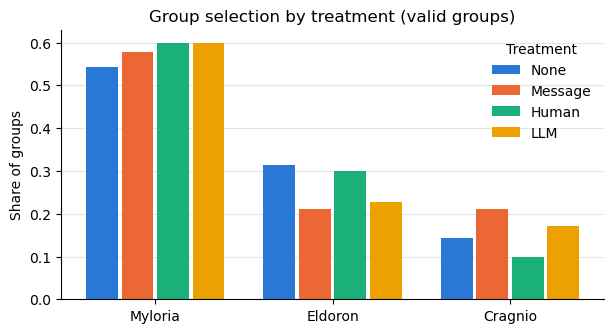

In [11]:
# Which city did groups choose?
CITIES = ["Myloria", "Eldoron", "Cragnio"]
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(CITIES))
width = 0.2
for i, t in enumerate(TREATMENTS):
    ax.bar(x + (i - 1.5) * width, selection.loc[t, CITIES], width * 0.9, label=t, color=TREATMENT_COLORS[t])
ax.set_xticks(x, CITIES)
ax.set_ylabel("Share of groups")
ax.set_title("Group selection by treatment (valid groups)")
ax.grid(axis="x", visible=False)
ax.legend(title="Treatment", frameon=False)
plt.show()

## 4. Utterances and Conversational Structure
Each game has a 1-minute `intro` phase and a ~10-minute `task` phase. Every utterance replies to the previous message, so each conversation is a single chain.

In [12]:
df_utts = corpus.get_utterances_dataframe()
df_utts.columns = [c.removeprefix("meta.") for c in df_utts.columns]
df_utts["treatment"] = df_utts["conversation_id"].map(treatment_of)
df_utts["is_ai"] = df_utts["speaker"].map(lambda sid: corpus.get_speaker(sid).is_ai)
print(df_utts["phase"].value_counts())
df_utts[["conversation_id", "speaker", "phase", "message_index", "time_since_task_start_min", "text"]].head()

phase
task     15983
intro     3348
Name: count, dtype: int64


,conversation_id,speaker,phase,message_index,time_since_task_start_min,text
id,,,,,,
01J9482GE8N55EH358ZZF19EKJ_intro_0,01J9482GE8N55EH358ZZF19EKJ,01J94A362Z46VFKEHV36491SWA,intro,0,None,Hello all !
01J9482GE8N55EH358ZZF19EKJ_intro_1,01J9482GE8N55EH358ZZF19EKJ,01J94A35WD7XK5N6SWK2565J8P,intro,1,None,Hello @[Pink] @[Green] @[Orange] @[Red]
01J9482GE8N55EH358ZZF19EKJ_intro_2,01J9482GE8N55EH358ZZF19EKJ,01J94A2REFNW2BZGSJM34N51MD,intro,2,None,@[Blue] @[Pink] @[Orange] @[Red] Hey!
01J9482GE8N55EH358ZZF19EKJ_intro_3,01J9482GE8N55EH358ZZF19EKJ,01J94A362Z46VFKEHV36491SWA,intro,3,None,Lets get started
01J9482GE8N55EH358ZZF19EKJ_intro_4,01J9482GE8N55EH358ZZF19EKJ,01J94A5JV67V5Y685DY78Q21JX,intro,4,None,@green @blue @pink @orange - Hi Hows it going?


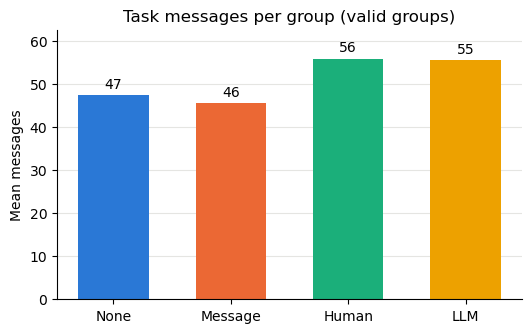

In [13]:
task_valid = df_utts[(df_utts["phase"] == "task") & df_utts["treatment"].notna()]
msgs_per_group = task_valid.groupby("conversation_id").size().groupby(treatment_of).mean()
treatment_bar(msgs_per_group, "Task messages per group (valid groups)", "Mean messages")

In [14]:
# Messages per group in the task phase, split by who sent them
by_sender = (task_valid.assign(sender=np.where(task_valid["is_ai"], "AI facilitator",
                                               np.where(task_valid["speaker"].map(lambda s: corpus.get_speaker(s).meta.get("game_role")) == "facilitator",
                                                        "Human facilitator", "Participants")))
             .groupby(["treatment", "sender"]).size()
             .div(pd.Series(Counter(treatment_of.values())), level="treatment")
             .unstack(fill_value=0).loc[TREATMENTS])
by_sender.round(1)

sender,AI facilitator,Human facilitator,Participants
treatment,,,
None,0.0,0.0,47.4
Message,0.0,0.0,45.5
Human,0.0,8.9,46.9
LLM,7.2,0.0,48.2


In [15]:
# Example transcript from an LLM-facilitated game
print(convo.get_transcript()[:2500])

Pink: Hello all !
Blue: Hello @[Pink] @[Green] @[Orange] @[Red]
Green: @[Blue] @[Pink] @[Orange] @[Red] Hey!
Pink: Lets get started
Red: @green @blue @pink @orange - Hi Hows it going?
Green: Pretty good!
Pink: @green @blue @pink @orange welcome all
Blue: Hope everyone is doing well today!
Orange: Hello
Pink: Lets get started !
Red: great!
Blue: Anyone have any preferences right off the bat?
Pink: All the choices seem really good.
Pink: I was reading through them and I think all would do well.
Blue: I'm thinking probably Eldoron might be best
Orange: Myloria sounds like the most entertaining city
Facilitator: @[Green], @[Red], we haven't heard from you yet. Could you share your thoughts on the three cities? Also, let's make sure we discuss the pros and cons of each city. @[Blue], @[Orange], could you elaborate on why you think Eldoron and Myloria are the best choices?
Red: it seems like the place with a temperate climate would be good for sports
Green: Yes all are great options.. first 

## 5. The LLM Facilitator
AI-generated utterances carry the exact model input (`ai_meta["config"]["messages"]`, OpenAI chat format) and the model's stated `rationale`. The call's log entry is in `meta["llm_call"]`.

In [16]:
ai_utt = next(u for u in convo.iter_utterances() if u.speaker.is_ai)
print(f"Utterance {ai_utt.id} (reply_to={ai_utt.reply_to})")
print("text:", ai_utt.text)
print("\nrationale:", ai_utt.ai_meta["rationale"])
print("\nmodel:", ai_utt.ai_meta["config"]["model"])
print("llm_call:", ai_utt.meta["llm_call"])
print("\nInput messages:")
for m in ai_utt.ai_meta["config"]["messages"]:
    content = m["content"] if len(m["content"]) < 300 else m["content"][:300] + " ..."
    print(f"  [{m['role']}] {content}")

Utterance 01J9482GE8N55EH358ZZF19EKJ_task_7 (reply_to=01J9482GE8N55EH358ZZF19EKJ_task_6)
text: @[Green], @[Red], we haven't heard from you yet. Could you share your thoughts on the three cities? Also, let's make sure we discuss the pros and cons of each city. @[Blue], @[Orange], could you elaborate on why you think Eldoron and Myloria are the best choices?

rationale: I chose this message to ensure that everyone has a chance to share their thoughts and to prompt the group to start discussing the pros and cons of each city. This will help in making a more informed decision.

model: gpt-4o-internal-07122024
llm_call: {'timestamp': 1727795740051, 'remainingTime': 509999, 'timeElapsed': 90001, 'intervalTriggered': True, 'requestMade': True, 'requestSuccess': True, 'reason': '', 'model': 'gpt-4o-internal-07122024', 'directlyRequested': False, 'requireLLMMessage': True, 'messageAdded': True}

Input messages:
  [system] A group of decision makers are meeting to decide on which of three cities

`convo.meta["llm_log"]` records every facilitator call, including ones that did not post a message (e.g. API errors, or skipping because the last message was already from the AI).

In [17]:
df_llm_log = pd.DataFrame([dict(e, conversation_id=c.id) for c in corpus.iter_conversations() for e in c.meta["llm_log"]])
print(f"{len(df_llm_log)} LLM calls across {df_llm_log['conversation_id'].nunique()} games")
print("\nmessageAdded:", df_llm_log["messageAdded"].value_counts(dropna=False).to_dict())
print("directlyRequested:", df_llm_log["directlyRequested"].value_counts().to_dict())
print("\nReasons for not posting:")
print(df_llm_log.loc[df_llm_log["reason"] != "", "reason"].value_counts())

582 LLM calls across 77 games

messageAdded: {True: 552, nan: 28, False: 2}
directlyRequested: {False: 462, True: 120}

Reasons for not posting:
reason
Last message was from AI, no request made                             17
API Error: Unexpected token 'S', "Sorry, an "... is not valid JSON     7
No chat messages available                                             6
Name: count, dtype: int64


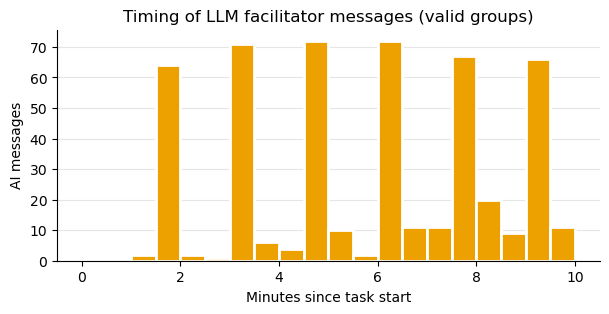

In [18]:
# When during the task does the facilitator speak?
ai_times = df_utts.loc[df_utts["is_ai"] & df_utts["treatment"].notna(), "time_since_task_start_min"]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ai_times, bins=np.arange(0, 10.5, 0.5), color=TREATMENT_COLORS["LLM"], edgecolor="white", linewidth=2)
ax.set_xlabel("Minutes since task start")
ax.set_ylabel("AI messages")
ax.set_title("Timing of LLM facilitator messages (valid groups)")
ax.grid(axis="x", visible=False)
plt.show()

## 6. Information Sharing
Task utterances list the facts they mention (`facts_mentioned`). A central question of the study is whether facilitation helps groups surface more of their distributed information, especially **private** facts held by only one person.

In [19]:
rows = []
for c in valid_convos:
    mentioned = {f for u in c.iter_utterances() if u.meta["phase"] == "task" for f in (u.meta.get("facts_mentioned") or [])}
    rows.append({
        "treatment": c.meta["treatment_label"],
        "unique_facts": len(mentioned),
        **{f"{v.lower()}_facts": len(mentioned & set(df_facts.index[df_facts["visibility"] == v]))
           for v in ["Public", "Shared", "Private"]},
    })
df_sharing = pd.DataFrame(rows)
fact_means = df_sharing.groupby("treatment").mean().loc[TREATMENTS]
fact_means.round(2)

,unique_facts,public_facts,shared_facts,private_facts
treatment,,,,
None,13.03,4.44,4.29,4.30
Message,14.35,4.94,4.34,5.07
Human,13.46,4.77,4.56,4.13
LLM,15.93,5.54,5.19,5.20


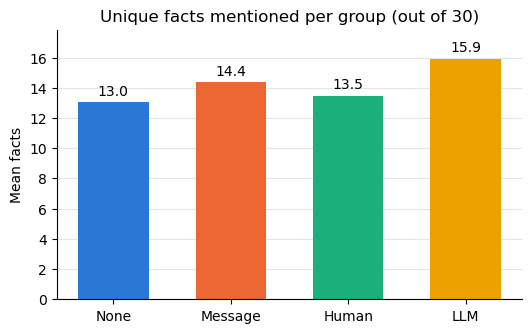

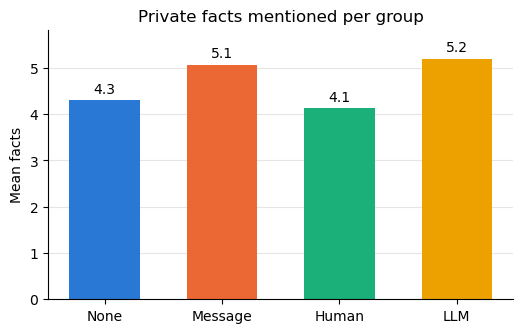

In [20]:
treatment_bar(fact_means["unique_facts"], "Unique facts mentioned per group (out of 30)", "Mean facts", fmt="{:.1f}")
treatment_bar(fact_means["private_facts"], "Private facts mentioned per group", "Mean facts", fmt="{:.1f}")

In [21]:
# Example message with detected facts
utt = next(u for u in convo.iter_utterances() if u.meta.get("facts_mentioned"))
print(f"{utt.speaker.meta['name']}: {utt.text}")
for fid in utt.meta["facts_mentioned"]:
    f = df_facts.loc[fid]
    print(f"  {fid}: {f['sports_info'].strip()} ({f['sports_option']}, {f['visibility']}, {f['polarity']})")

Green: Yes all are great options.. first thing that stands out for me is how Eldoron has a strong culture for sports and fitness
  E10: Strong culture of sports and fitness (Eldoron, Shared, Positive)


## 7. Post-task Surveys
Each human speaker's metadata includes their post-task survey (`subjective_survey`), NASA-TLX workload (`tlx_survey`), agreement with the group decision, and free-text feedback. Participants who never sent a message are not speakers, but their responses are kept in `convo.meta["silent_players"]`.

In [22]:
# Collect every participant in a valid group, including silent players
participants = []
for c in valid_convos:
    for s in c.iter_speakers():
        if not s.is_ai and s.meta.get("game_role") == "participant":
            participants.append(dict(s.meta))
    participants.extend(c.meta["silent_players"].values())
df_part = pd.DataFrame(participants)
df_part["treatment"] = df_part["game_id"].map(treatment_of)
survey = pd.json_normalize(df_part["subjective_survey"])
survey = survey.where(survey != "")
df_part = pd.concat([df_part.drop(columns=["subjective_survey"]), survey], axis=1)
print(f"{len(df_part)} participants in valid groups")
df_part[["name", "treatment", "selected_option", "agreement", "groupContribution", "groupProductive", "facilitatorPreference"]].head()

1405 participants in valid groups


,name,treatment,selected_option,agreement,groupContribution,groupProductive,facilitatorPreference
0,Blue,LLM,Myloria,100.0,5,5,human
1,Orange,LLM,Myloria,100.0,5,5,no
2,Red,LLM,Myloria,100.0,5,5,ai
3,Green,LLM,Myloria,100.0,5,5,ai
4,Pink,LLM,Myloria,92.0,4,4,ai


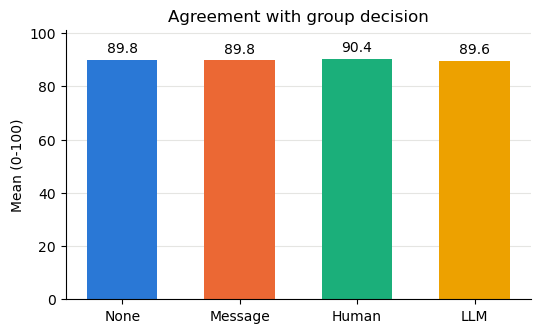

In [23]:
treatment_bar(df_part.groupby("treatment")["agreement"].mean(), "Agreement with group decision", "Mean (0-100)", fmt="{:.1f}")

In [24]:
# Group perception items (1-5 Likert) by treatment
items = ["groupContribution", "groupInfluence", "groupProductive", "groupStructured"]
df_part[items].astype(float).groupby(df_part["treatment"]).mean().loc[TREATMENTS].round(2)

,groupContribution,groupInfluence,groupProductive,groupStructured
treatment,,,,
None,4.54,3.82,4.42,3.87
Message,4.50,3.93,4.45,3.80
Human,4.59,3.86,4.46,3.81
LLM,4.58,3.90,4.46,3.95


In [25]:
# "Would you prefer a facilitator in future discussions?" (ai / human / no)
pd.crosstab(df_part["treatment"], df_part["facilitatorPreference"], normalize="index").loc[TREATMENTS].round(2)

facilitatorPreference,ai,human,no
treatment,,,
None,0.09,0.18,0.73
Message,0.08,0.15,0.77
Human,0.08,0.82,0.11
LLM,0.63,0.27,0.09


In [26]:
# Free-text impressions of the LLM facilitator
llm_feedback = df_part.loc[(df_part["treatment"] == "LLM") & df_part["facilitatorGroupFreetext"].notna(), "facilitatorGroupFreetext"]
for text in llm_feedback.head(5):
    print("-", text)

- The facilitator was good at keeping us on track with time by gently nudging us with pros and cons and to make a final choice.
- The facilitator was kind of annoying. They were asking us to type out way too much.
- Good questions and moderation
- I felt the facilitator helped regulate the conversation
- I felt they helped us a lot, they guided us well.


## 8. Evaluating Facilitation with ConvoKitAI Evaluation
The treatments make it possible to ask how facilitation changes the conversation itself, not just the outcome. `convokitai_evaluation` gives three conversation-level measures:

- **CIG** (conversational information gain): an LLM rates each message 1–4 for how much it adds to what the group already knew. This shows whether facilitator messages, and participant messages under each treatment, move the discussion forward.
- **ClaimTracker**: follows the claims each participant holds from their personal fact report to the end of the chat. This shows how far the group's information converges and how much of it the facilitator introduced.
- **MediatorRedirection**: for each facilitator message, a language model estimates how much it changed the participant reply that followed.

To install it, run `python -m pip install -e . -e ./convokit/convokitai_evaluation` from the repository root. CIG and ClaimTracker call OpenAI (`GPT_API_KEY`), and MediatorRedirection runs Gemma from Hugging Face (`HF_TOKEN`).

### Setup for This Corpus
The metrics need to know who the facilitator is, what the discussion is about, and (for ClaimTracker) where each participant starts. In this corpus:

- **Facilitators** have `game_role == "facilitator"`. This covers both the LLM facilitator (an AI speaker) and the human facilitators, so the Human and LLM treatments are scored the same way. The metrics show both as "Mediator(mod)".
- **The topic** is the same city-selection task in every game; we give it as one line rather than the full `general_info` brief.
- **Starting positions** come from each participant's personal fact report, the part of `player_content` after `# Personal report delivered to`. The report is the information that participant brought to the chat.
- **Speaker names** come from `convo.alias`, so messages appear under the color names participants used (`Blue: ...`).

The metrics make one or more LLM calls per message, and groups average about 58 messages, so we run them on a few valid groups per treatment. Increase `N_PER_TREATMENT` for a full analysis.

In [ ]:
import os

os.environ["GPT_API_KEY"] = "sk-"
os.environ["HF_TOKEN"] = "hf_"

from convokitai_evaluation import CIG, ClaimTracker, MediatorRedirection

TOPIC = ("Choosing which of three cities (Eldoron, Myloria, Cragnio) should host a large sporting event; "
         "each decision maker holds a different subset of facts about the cities")
REPORT_HEADER = "# Personal report delivered to"


def is_facilitator(speaker):
    """LLM and human facilitators alike (the default only recognizes the LLM one)."""
    return speaker.meta.get("game_role") == "facilitator"


def topic(convo):
    return TOPIC


def personal_report(convo, speaker):
    """A participant's private fact report, without the task brief everyone shares."""
    content = speaker.meta.get("player_content") or ""
    return REPORT_HEADER + content.split(REPORT_HEADER, 1)[1] if REPORT_HEADER in content else None


print(personal_report(convo, human))

In [ ]:
# A few valid groups per treatment; ClaimTracker and MediatorRedirection only need the facilitated ones
N_PER_TREATMENT = 2
sample_ids = {t: sorted(c.id for c in valid_convos if c.meta["treatment_label"] == t)[:N_PER_TREATMENT]
              for t in TREATMENTS}
sampled = {cid for ids in sample_ids.values() for cid in ids}
in_sample = lambda c: c.id in sampled
facilitated = lambda c: in_sample(c) and c.meta["treatment_label"] in ("Human", "LLM")
llm_convo = corpus.get_conversation(sample_ids["LLM"][0])
sample_ids

### CIG: Conversational Information Gain
CIG also runs on the None and Message groups, which have no facilitator, so participant messages can be compared across all four treatments.

CIG doesn't rate the opening exchange, up to and including the first message by which every speaker has spoken. The LLM facilitator first speaks about 90 seconds into the task, so about 13% of task messages in LLM groups go unrated, compared with 2–6% in the other treatments. Keep this in mind when comparing treatments.

In [ ]:
cig = CIG(model="gpt-5", is_mediator=is_facilitator, topic_func=topic)
cig.transform(corpus, selector=in_sample)

In [ ]:
# Per message: 1 (no gain) .. 4 (insightful); None = opening exchange or too short to rate
for utt in llm_convo.get_chronological_utterance_list():
    if utt.meta["phase"] == "task":
        print(utt.meta["cig"], llm_convo.alias.get(utt.speaker.id, utt.speaker.id), ":", utt.text[:90])

In [ ]:
# Mean CIG per group, facilitator vs participant messages, averaged by treatment
cig_summary = cig.summarize(corpus, selector=in_sample)
cig_summary["treatment"] = cig_summary["conversation_id"].map(treatment_of)
cig_summary["sender"] = np.where(cig_summary["is_mediator"], "Facilitator", "Participants")
cig_summary.groupby(["treatment", "sender"])["cig_mean"].mean().unstack().reindex(TREATMENTS).round(2)

### ClaimTracker: Information Convergence
Because each participant starts from their personal report, the initial claims are the facts they were dealt, and `agreement_gain` measures how far the group's *information* converged during the chat (not a change of opinion). Agreement is judged between every pair of the five participants (10 pairs per group).

`share_from_mediator` is the share of a participant's final claims that the facilitator stated first, a direct measure of what the facilitator surfaced. The fact-level counterpart is `facts_mentioned` (Section 6).

In [ ]:
# Downloads the Qwen3 embedding and DeBERTa NLI models on first run
tracker = ClaimTracker(model="gpt-5-mini", is_mediator=is_facilitator, topic_func=topic,
                       seed_text_func=personal_report)
tracker.transform(corpus, selector=facilitated)

In [ ]:
# What one participant held before (their report) and after the conversation
record = llm_convo.meta["claims"]
name = list(record["initial"])[0]
print(f"== {name}: before")
print("\n".join("  - " + c for c in record["initial"][name]))
print(f"== {name}: after")
print("\n".join("  - " + c for c in record["final"][name]))

In [ ]:
# Claims the facilitator stated first, with the turn it said them at
for m in record["memory"]:
    if m["role"] == "mediator" and m["kind"] == "own":
        print(f"turn {m['first_turn']:>3}: {m['claim'][:100]}")

In [ ]:
# Agreement across all participant pairs, before and after
{k: v for k, v in record["agreement"].items() if k != "pairs"}

In [ ]:
# Per participant: where their final claims came from; agreement_gain is the group's
claims_summary = tracker.summarize(corpus, selector=facilitated)
claims_summary["treatment"] = claims_summary["conversation_id"].map(treatment_of)
claims_summary.groupby("treatment")[["agreement_gain", "share_from_mediator", "share_from_partner",
                                     "share_new_common_ground"]].mean().round(2)

### MediatorRedirection: Did the Facilitator Steer the Conversation?
A facilitator message gets a score when a participant message comes before it, there is an earlier facilitator message to compare against, and a participant replies to it. The LLM facilitator posts about every 90 seconds, so a typical LLM group has around 5–6 scored messages. Positive scores mean the reply was more expected after this message than after the facilitator's previous one.

In [ ]:
from convokit.redirection.config import DEFAULT_LORA_CONFIG, DEFAULT_TRAIN_CONFIG
from convokit.redirection.gemmaLikelihoodModel import GemmaLikelihoodModel

# Off-the-shelf model, no fine-tuning
likelihood_model = GemmaLikelihoodModel(
    hf_token=os.getenv("HF_TOKEN"),
    model_id="google/gemma-2b",
    device="mps",  # "cuda" | "mps" | "cpu"
    train_config=dict(DEFAULT_TRAIN_CONFIG, max_seq_length=2048),
    bnb_config=None,  # 4-bit quantization needs CUDA
    lora_config=DEFAULT_LORA_CONFIG,
)
redirection = MediatorRedirection(likelihood_model, counterfactual="prev", is_mediator=is_facilitator)
redirection.transform(corpus, selector=facilitated)

In [ ]:
# One score per facilitator turn that a participant replied to
for utt in llm_convo.iter_utterances():
    if utt.meta.get("redirection") is not None:
        print(f"{utt.meta['redirection']:+.2f}", utt.text[:90])

In [ ]:
redirection_summary = redirection.summarize(corpus, selector=facilitated)
redirection_summary["treatment"] = redirection_summary["conversation_id"].map(treatment_of)
redirection_summary.groupby("treatment")[["n_scored", "redirection_mean"]].mean().round(2)

### Comparing the Metrics with Participants' Ratings
Participants rated their facilitator in the post-task survey (Section 7): whether it helped everyone share (`facilitatorSharing`), synthesized the discussion (`facilitatorSynthesis`), kept the group focused (`facilitatorFocus`), or was distracting (`facilitatorDistracting`). The table puts each facilitated group's metrics next to those ratings. With only a few groups per treatment this is an illustration, not a result.

In [ ]:
rating_items = ["facilitatorSharing", "facilitatorSynthesis", "facilitatorFocus", "facilitatorDistracting"]
ratings = df_part[df_part["treatment"].isin(["Human", "LLM"])].groupby("game_id")[rating_items].agg(
    lambda x: x.astype(float).mean())

per_group = pd.DataFrame({
    "treatment": pd.Series(treatment_of),
    "facilitator_cig": cig_summary[cig_summary["is_mediator"]].set_index("conversation_id")["cig_mean"],
    "agreement_gain": claims_summary.groupby("conversation_id")["agreement_gain"].first(),
    "redirection_mean": redirection_summary.set_index("conversation_id")["redirection_mean"],
}).join(ratings).loc[[cid for cid in sampled if treatment_of[cid] in ("Human", "LLM")]]
per_group.round(2)